In [ ]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, START, END
# StateGraph is a framework that help to design and manage the flow of tasks using graph structure.

In [2]:
class AgentState(TypedDict):
    num1: int
    num2: int
    operator: str
    final_num: int

In [ ]:
def adder(state: AgentState) -> AgentState:
    """This node add two numbers"""
    state['final_num'] = state['num1'] + state['num2']
    return state
def subtractor(state: AgentState) -> AgentState:
    """This node subtract two numbers"""
    state['final_num'] = state['num1'] - state['num2']
    return state
def decision_node(state: AgentState) -> AgentState: # This node is returning the edge not state!!!
    """This is the router node"""
    if state['operator'] == "+":
        return 'addition-operator'
    elif state['operator'] == "-":
        return 'subtraction-operator'

In [12]:
graph = StateGraph(AgentState)
graph.add_node('add-node', adder)
graph.add_node('subtract-node', subtractor)
graph.add_node('router', lambda state:state) # Passthrough function(state-in state-out nothing happen)
graph.add_edge(START, 'router')
graph.add_conditional_edges(
    'router',                                      # Source node
    decision_node,                                 # Function that decides
    {
        'addition-operator': 'add-node',
        'subtraction-operator': 'subtract-node'
    }
)
graph.add_edge('add-node', END)
graph.add_edge('subtract-node', END)
app = graph.compile()

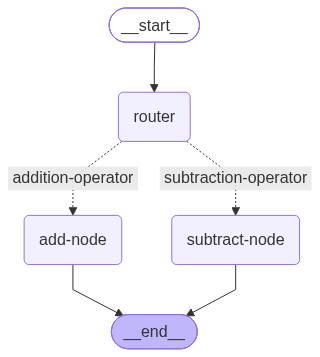

In [13]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
state_1 = AgentState(
    num1=13, num2=10, operator='-'
)
result = app.invoke(state_1)
result['final_num']

3